<style>
div.text_cell_render {
    font-size: 16px;
    color: #333333;
}
</style>


<style>
div.text_cell_render {
    font-size: 46px;
    color: #333333;
}
</style>


## E-commerce Data Analysis Project

This project analyzes e-commerce data to gain insights into various aspects of the business, including:

- Sales performance  
- Customer behavior  
- Product trends  
- Operational efficiency  

### Key Areas of Analysis

- Revenue trends  
- Top-selling products  
- Customer lifetime value  
- Return rates  
- Inventory health  
- Employee performance  
- Payment method breakdowns  

### Objective

The goal is to provide data-driven recommendations for improving business strategies and operations.

# Import Libraries

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import requests


# Create a New SQLite Database

In [7]:
# Connect to SQLite
conn = sqlite3.connect("ecommerce.db", timeout=3000)
cursor = conn.cursor()

# GitHub API URL for the folder contents
github_api_url = "https://api.github.com/repos/BrianKvin/sample_data/contents/e-commerce_data"

# Fetch the list of files
response = requests.get(github_api_url)
files = response.json()

# Iterate over each file
for file in files:
    if file["name"].endswith(".csv"):
        # Construct the raw URL for the CSV file
        raw_url = file["download_url"]
        table_name = file["name"].replace(".csv", "")
        df = pd.read_csv(raw_url)
        df.to_sql(table_name, conn, if_exists="replace", index=False)

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in the database:", tables)

#conn.close()


Tables in the database: [('customers',), ('employees',), ('inventory',), ('order_items',), ('orders',), ('payments',), ('products',), ('returns',), ('reviews',), ('suppliers',)]



### What is the total revenue (order items + shipping cost) for the entire period?



In [8]:

query = """ SELECT 
    SUM(oi.total_cost + o.shipping_cost) AS total_revenue
FROM (
    SELECT
        order_id,
        SUM(quantity * unit_price) AS total_cost 
    FROM order_items
    GROUP BY order_id) oi
JOIN orders o ON o.order_id = oi.order_id
  ;"""


total_revenue = pd.read_sql(query, conn)
total_revenue


,total_revenue
0,14475589.06



### What are the top 10 best-selling products by quantity sold and by revenue?



In [11]:
query = """ SELECT pr.product_name,
        pr.product_id,
      SUM(oi.quantity) AS quantity, 
      SUM(oi.quantity*oi.unit_price) AS revenue
       FROM products pr
        JOIN order_items oi ON pr.product_id = oi.product_id
        GROUP BY pr.product_id
        ORDER BY quantity DESC
        LIMIT 10
        ;
        """
top_quantity = pd.read_sql(query, conn)
top_quantity

,product_name,product_id,quantity,revenue
0,IKEA Bath Towel Set,343,91,15916.81
1,Nike Action Figure Set,290,81,3461.13
2,IKEA Men's Crew Socks 10-Pack,1299,80,4831.20
3,"Hasbro 55"" 4K Smart TV",830,79,115974.37
4,Mattel 1000-Piece Puzzle,1045,78,2354.04
5,Adidas Whole Milk 1 Gallon,1013,78,1316.64
6,LG Fluoride Toothpaste,722,78,2388.36
7,Old Navy Cotton T-Shirt,1304,77,2190.65
8,Kelloggs Daily Shampoo 12oz,905,77,1749.44
9,Procter & Gamble Women's Slim Jeans,300,76,7935.92


In [13]:
query = """ SELECT pr.product_name,
        pr.product_id,
      SUM(oi.quantity) AS quantity, 
      SUM(oi.quantity*oi.unit_price) AS revenue
       FROM products pr
        JOIN order_items oi ON pr.product_id = oi.product_id
        GROUP BY pr.product_id
        ORDER BY revenue DESC
        LIMIT 10
        ;
        """
top_revenue = pd.read_sql(query, conn)
top_revenue

,product_name,product_id,quantity,revenue
0,"Hasbro 55"" 4K Smart TV",830,79,115974.37
1,LG Wireless Headphones,321,75,99001.50
2,"Old Navy Laptop 15""",72,63,91175.49
3,KitchenAid Smartphone 128GB,1266,60,88531.80
4,"Coca-Cola Laptop 15""",472,60,88276.80
5,"IKEA 55"" 4K Smart TV",385,58,86209.46
6,"Adidas Laptop 15""",1251,59,86092.21
7,"Sony Laptop 15""",1032,58,81889.04
8,"Old Navy Laptop 15""",433,63,81626.58
9,"KitchenAid Laptop 15""",186,55,81254.80


***

### What are the top 5 categories by revenue and by number of units sold?



In [14]:
query = """SELECT 
    pr.category, 
    SUM(oi.quantity) as units_sold,
    SUM (oi.unit_price * oi.quantity) AS total_revenue
FROM products as pr
JOIN order_items AS oi ON oi.product_id = pr.product_id
GROUP BY pr.category
ORDER BY units_sold DESC
LIMIT 5;
"""
top_category_revenue = pd.read_sql(query, conn)
top_category_revenue

,category,units_sold,total_revenue
0,Home & Kitchen,12527,2082666.81
1,Toys,12352,676373.20
2,Grocery,12214,130069.85
3,Electronics,12203,9902962.50
4,Clothing,11801,1247363.33


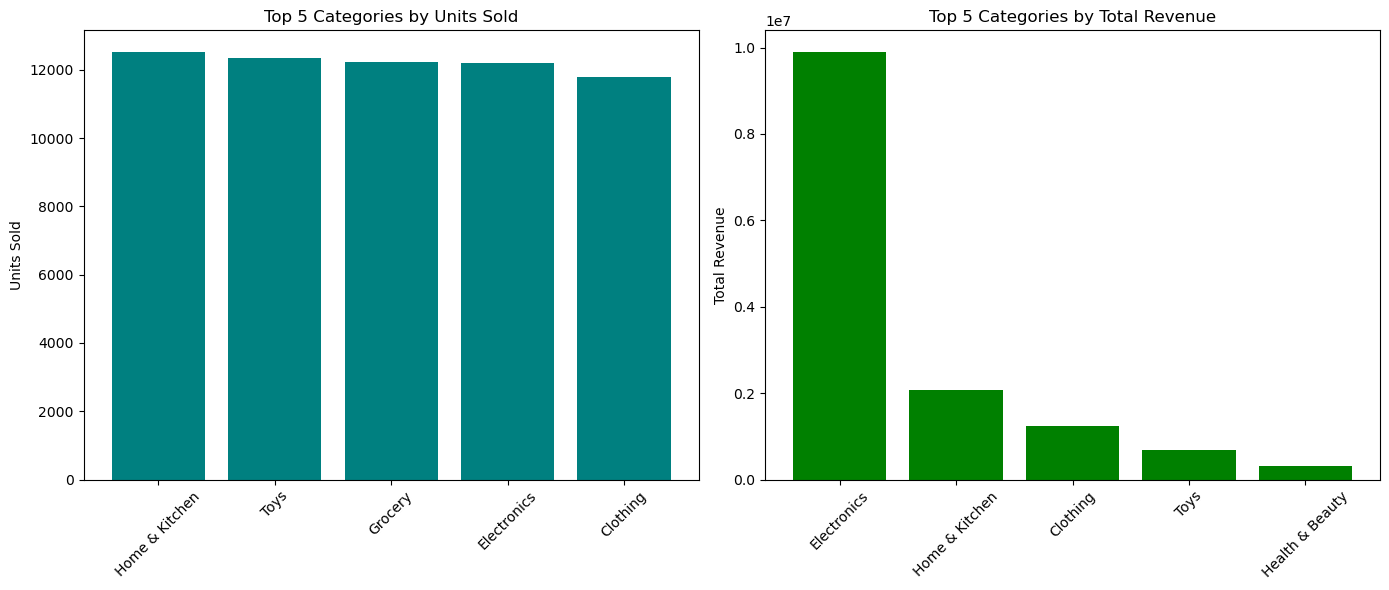

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 5 Categories by Units Sold
axes[0].bar(top_category_revenue['category'], top_category_revenue['units_sold'], color='teal')
axes[0].set_title('Top 5 Categories by Units Sold')
axes[0].set_ylabel('Units Sold')
axes[0].tick_params(axis='x', rotation=45)

# Top 5 Categories by Total Revenue
axes[1].bar(top_category_sold['category'], top_category_sold['total_revenue'], color='green')
axes[1].set_title('Top 5 Categories by Total Revenue')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [28]:
query = """SELECT 
    pr.category, 
    SUM(oi.quantity) as units_sold,
    SUM (oi.unit_price * oi.quantity) AS total_revenue
FROM products as pr
JOIN order_items AS oi ON oi.product_id = pr.product_id
GROUP BY pr.category
ORDER BY total_revenue DESC
LIMIT 5;
"""
top_category_sold = pd.read_sql(query, conn)
top_category_sold

,category,units_sold,total_revenue
0,Electronics,12203,9902962.50
1,Home & Kitchen,12527,2082666.81
2,Clothing,11801,1247363.33
3,Toys,12352,676373.20
4,Health & Beauty,10891,315347.89


***


### Monthly revenue trend (2022–2025) – show year-month and total revenue



In [32]:
query = """SELECT
    strftime('%Y-%m', date(o.order_date)) AS year_month,
    SUM(order_revenue + o.shipping_cost) AS total_revenue
FROM orders o
JOIN (
    SELECT
        order_id,
        SUM(quantity * unit_price) AS order_revenue
    FROM order_items
    GROUP BY order_id
) oi
    ON o.order_id = oi.order_id
WHERE date(o.order_date) BETWEEN '2022-01-01' AND '2025-12-31'
GROUP BY year_month
ORDER BY year_month;
"""
monthly_trend = pd.read_sql(query, conn)
monthly_trend

,year_month,total_revenue
0,2022-01,339045.30
1,2022-02,290592.26
2,2022-03,289223.14
3,2022-04,320317.94
4,2022-05,287782.80
5,2022-06,296421.53
6,2022-07,361292.10
7,2022-08,351151.96
8,2022-09,313269.30
9,2022-10,348203.67


### Which customers have spent the most (lifetime value)? Show top 20 customers with total spent and number of orders



In [34]:
query = """SELECT c.customer_id, 
           CONCAT(c.first_name, " ", c.last_name) AS CustomerName,
           COUNT(DISTINCT o.order_id) AS TotalOrders,
          SUM(oi.revenue + o.shipping_cost) AS AmountSpent
FROM customers c
JOIN orders o
    ON o.customer_id = c.customer_id
JOIN (SELECT order_id,
SUM (quantity * unit_price) AS revenue
 FROM order_items
 GROUP BY order_id) oi
  ON o.order_id = oi.order_id

GROUP BY c.customer_id
ORDER BY AmountSpent DESC
LIMIT 20

"""
top_customers = pd.read_sql (query, conn)
top_customers

,customer_id,CustomerName,TotalOrders,AmountSpent
0,6857,Chris Martinez,4,17130.00
1,1155,John Jones,5,14605.41
2,4234,Robert Martin,4,14517.00
3,2393,Mary Martin,4,13622.97
4,322,Lisa Lopez,5,13375.78
5,4882,John Garcia,3,13097.61
6,3979,Anna Thomas,5,13082.73
7,5935,Emily Wilson,3,13007.78
8,438,Patricia Martinez,5,12991.60
9,7739,Sarah Gonzalez,2,12927.27


### What is the average order value (AOV) overall and by year/month?



In [36]:
query = """ SELECT
    ROUND(SUM(oi.order_revenue + o.shipping_cost) / COUNT(DISTINCT o.order_id), 2) AS overall_aov
FROM orders o
JOIN (
    SELECT
        order_id,
        SUM(quantity * unit_price) AS order_revenue
    FROM order_items
    GROUP BY order_id
) oi
    ON o.order_id = oi.order_id
"""
order_value = pd.read_sql (query, conn)
order_value

,overall_aov
0,1206.3


In [37]:
query = """ SELECT strftime('%Y', o.order_date) AS Year,
    ROUND(SUM(oi.order_revenue + o.shipping_cost) / COUNT(DISTINCT o.order_id), 2) AS overall_aov
FROM orders o
JOIN (
    SELECT
        order_id,
        SUM(quantity * unit_price) AS order_revenue
    FROM order_items
    GROUP BY order_id
) oi
    ON o.order_id = oi.order_id
    GROUP BY YEAR 
"""
order_value = pd.read_sql (query, conn)
order_value

,Year,overall_aov
0,2022,1233.14
1,2023,1190.19
2,2024,1192.18
3,2025,1210.18


In [38]:
query = """ SELECT strftime('%Y-%m', o.order_date) AS Year_Month,
    ROUND(SUM(oi.order_revenue + o.shipping_cost) / COUNT(DISTINCT o.order_id), 2) AS overall_aov
FROM orders o
JOIN (
    SELECT
        order_id,
        SUM(quantity * unit_price) AS order_revenue
    FROM order_items
    GROUP BY order_id
) oi
    ON o.order_id = oi.order_id
    GROUP BY Year_Month 
"""
order_value = pd.read_sql (query, conn)
order_value

,Year_Month,overall_aov
0,2022-01,1350.78
1,2022-02,1297.29
2,2022-03,1121.02
3,2022-04,1318.18
4,2022-05,1160.41
5,2022-06,1167.01
6,2022-07,1196.33
7,2022-08,1300.56
8,2022-09,1299.87
9,2022-10,1234.76


### Customer retention: How many customers made more than one purchase? What % of total customers are repeat buyers?



In [40]:
query=""" SELECT COUNT(*) AS repeat_buyers
FROM(
SELECT c.customer_id,
COUNT(o.order_id) AS no_of_orders
FROM customers c
JOIN orders o
ON o.customer_id = c.customer_id
GROUP BY c.customer_id
HAVING no_of_orders > 1)t
"""
customers = pd.read_sql(query, conn)
customers

,repeat_buyers
0,3535


In [41]:
query=""" WITH cte_repeat_buyers AS(
SELECT COUNT(*) AS repeat_buyers
FROM(
SELECT c.customer_id,
COUNT(o.order_id) AS no_of_orders
FROM customers c
JOIN orders o
ON o.customer_id = c.customer_id
GROUP BY c.customer_id
HAVING no_of_orders > 1)),

 cte_total_customers AS (
 SELECT COUNT(DISTINCT customer_id) AS all_customers
 FROM customers)

 SELECT 
 crb.repeat_buyers * 100.0 /CAST(ctc.all_customers AS FLOAT) AS percent_repeat_buyers
 FROM cte_repeat_buyers crb, cte_total_customers ctc
"""
customers = pd.read_sql(query, conn)
customers

,percent_repeat_buyers
0,44.1875



### Which products have the highest return rate (% of order_items returned)? Show top 10



In [17]:
query = """
SELECT 
    p.product_name,
    COUNT(oi.order_item_id) AS total_items_sold,
    COUNT(r.return_id) AS items_returned,
    ROUND(COUNT(r.return_id) * 100.0 / COUNT(oi.order_item_id), 2) AS return_rate_percent
FROM products p
JOIN order_items oi ON p.product_id = oi.product_id
LEFT JOIN returns r ON oi.order_item_id = r.order_item_id
GROUP BY p.product_name
HAVING total_items_sold > 0
ORDER BY return_rate_percent DESC
LIMIT 10
"""
returned_orders = pd.read_sql(query, conn)
returned_orders

,product_name,total_items_sold,items_returned,return_rate_percent
0,KitchenAid Bath Towel Set,24,5,20.83
1,Pepsi Sliced Bread 20oz,49,10,20.41
2,Pepsi Whole Milk 1 Gallon,47,9,19.15
3,Maybelline Upright Vacuum,16,3,18.75
4,Levis Fluoride Toothpaste,12,2,16.67
5,Hanes Running Shoes,58,9,15.52
6,Hasbro Cotton T-Shirt,84,13,15.48
7,Kelloggs Fluoride Toothpaste,66,10,15.15
8,Old Navy Daily Shampoo 12oz,47,7,14.89
9,Coca-Cola Action Figure Set,89,13,14.61


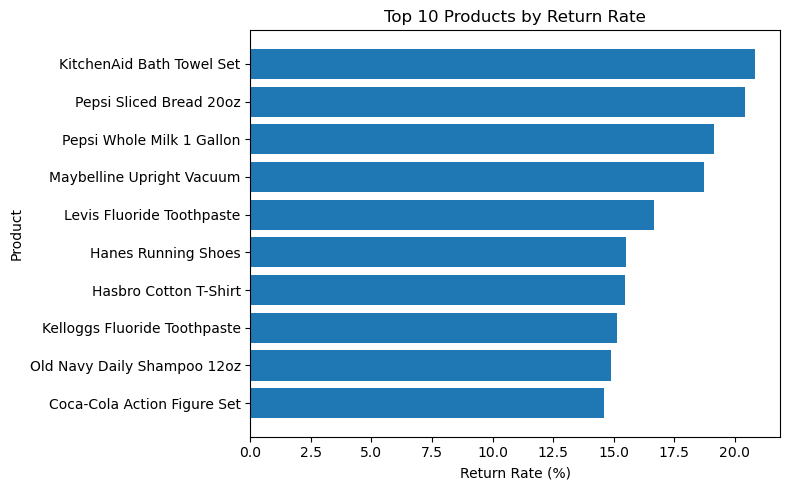

In [19]:
plt.figure(figsize=(8, 5))

plt.barh(
    returned_orders['product_name'],
    returned_orders['return_rate_percent']
)

plt.title('Top 10 Products by Return Rate')
plt.xlabel('Return Rate (%)')
plt.ylabel('Product')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



### What are the most common return reasons by category?



In [46]:
query = """
SELECT 
category,
reason_code,
reason_count
FROM(
SELECT 
p.category AS category,
r.reason_code AS reason_code,
COUNT(r.reason_code) AS reason_count,
ROW_NUMBER() OVER(PARTITION BY p.category ORDER BY COUNT(r.reason_code) DESC) AS ranking
FROM products p
JOIN order_items oi ON p.product_id = oi.product_id
LEFT JOIN returns r ON oi.order_item_id = r.order_item_id
WHERE reason_code IS NOT NULL
GROUP BY p.category,r.reason_code
ORDER BY p.category, reason_count DESC )t
WHERE ranking = 1
"""
return_reasons = pd.read_sql(query, conn)
return_reasons

,category,reason_code,reason_count
0,Clothing,wrong item,89
1,Electronics,damaged,94
2,Grocery,customer remorse,95
3,Health & Beauty,wrong item,82
4,Home & Kitchen,defective,90
5,Toys,late delivery,98


### Which suppliers are associated with the highest-return products?



In [48]:
query ="""
SELECT
s.supplier_name, 
COUNT(oi.order_item_id) AS total_sold,
COUNT(r.return_id) AS no_of_returns,
ROUND((COUNT(r.return_id)/CAST(COUNT(oi.order_item_id) AS FLOAT)*100), 2) AS return_percentage
FROM suppliers s
JOIN products p ON s.supplier_id = p.supplier_id
JOIN order_items oi ON oi.product_id = p.product_id
LEFT JOIN returns r ON r.order_item_id = oi.order_item_id
GROUP BY s.supplier_name
ORDER BY return_percentage DESC
LIMIT 10
"""
worst_suppliers = pd.read_sql(query, conn)
worst_suppliers

,supplier_name,total_sold,no_of_returns,return_percentage
0,Tech Distributors LLC #17,250,31,12.40
1,Global Suppliers Inc. #16,74,9,12.16
2,Tech Distributors LLC #4,75,9,12.00
3,Tech Distributors LLC #18,35,4,11.43
4,Fresh Foods Co. #49,70,8,11.43
5,Fresh Foods Co. #37,80,9,11.25
6,Tech Distributors LLC #16,143,16,11.19
7,Tech Distributors LLC #40,122,13,10.66
8,Apparel Wholesalers #46,104,11,10.58
9,Tech Distributors LLC #32,315,33,10.48



### Inventory health: Which products have stock < 10 and have sold > 50 units in the last 30 days? (stock-out risk)



In [50]:
query = """
SELECT 
p.product_id,
p.product_name,
p.category,
i.stock_quantity,
COALESCE(SUM(oi.quantity), 0) AS units_sold_last_30_days
FROM products p
JOIN inventory i ON p.product_id = i.product_id
JOIN order_items oi ON p.product_id = oi.product_id
JOIN orders o ON oi.order_id = o.order_id 
WHERE i.stock_quantity < 10
    AND JULIANDAY((SELECT MAX(order_date) FROM orders)) - JULIANDAY(o.order_date) <= 30
GROUP BY p.product_id, p.product_name, p.category, i.stock_quantity
HAVING units_sold_last_30_days > 50
ORDER BY units_sold_last_30_days DESC
"""
stockout_risk = pd.read_sql(query, conn)
stockout_risk

,product_id,product_name,category,stock_quantity,units_sold_last_30_days



### Employee performance: Which employees processed the highest revenue and the most orders? Top 10 leaderboard



In [52]:
query = """
SELECT 
e.first_name || ' ' || e.last_name AS employee_name,
COUNT(DISTINCT o.order_id) AS total_orders_processed,
ROUND(SUM(order_totals.items_total + o.shipping_cost), 2) AS total_revenue
FROM employees e
JOIN orders o ON o.employee_id = e.employee_id
JOIN (
SELECT 
order_id,
 SUM(quantity * unit_price) AS items_total
  FROM order_items
GROUP BY order_id
) order_totals ON o.order_id = order_totals.order_id
GROUP BY e.employee_id, e.first_name, e.last_name
ORDER BY total_revenue DESC, total_orders_processed DESC
LIMIT 10
"""
top_employees = pd.read_sql(query, conn)
top_employees

,employee_name,total_orders_processed,total_revenue
0,Christopher Miller,31,57196.97
1,William Smith,36,55147.70
2,Thomas Miller,33,54455.33
3,Elizabeth Thomas,35,54442.55
4,John Martin,32,54193.74
5,David Johnson,31,53571.21
6,Mary Smith,26,53315.09
7,Anna Jackson,36,50621.13
8,Linda Lopez,21,50250.79
9,Jennifer Thomas,34,49757.84



### Payment method breakdown: % of revenue and orders by payment method (card, PayPal, gift card)



In [54]:
query = """
SELECT 
CASE 
WHEN payment_method IN ('card', 'debit_card', 'credit_card') THEN 'Card Payment'
WHEN payment_method = 'PayPal' THEN 'Paypal'
WHEN payment_method = 'gift_card' THEN 'Gift Card' ELSE 'Other'
END AS payment_category,
COUNT(DISTINCT order_id) AS num_orders,
ROUND(SUM(amount), 2) AS total_revenue
FROM payments
WHERE payment_status = 'Completed'
GROUP BY payment_category
ORDER BY total_revenue DESC
"""
payment_breakdown = pd.read_sql(query, conn)
payment_breakdown

,payment_category,num_orders,total_revenue
0,Other,1359,1681191.73
1,Paypal,1387,1669742.80
2,Card Payment,1333,1615025.93


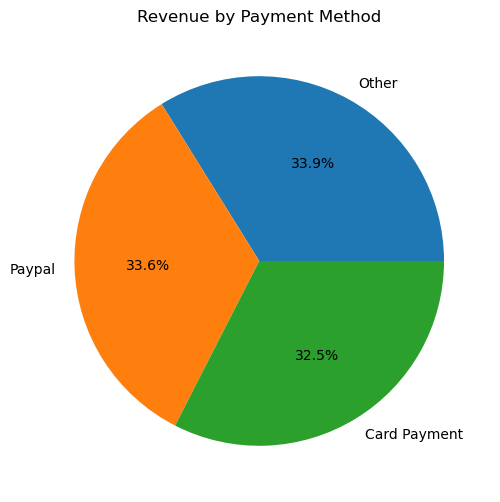

In [55]:
# Simple pie chart of payment breakdown by revenue
plt.figure(figsize=(6, 6))
plt.pie(
    payment_breakdown['total_revenue'],
    labels=payment_breakdown['payment_category'],
    autopct='%1.1f%%'
)
plt.title('Revenue by Payment Method')
plt.show()


### Average rating per category and per brand – highlight categories/brands with < 3.0 average rating



In [57]:
query = """
SELECT 
p.brand,
COUNT(r.review_id) AS num_reviews,
ROUND(AVG(r.rating), 2) AS avg_rating,
CASE 
WHEN AVG(r.rating) < 3.0 THEN 'LOW'
ELSE 'OK' END AS rating_status
FROM products p
JOIN reviews r ON p.product_id = r.product_id
GROUP BY p.brand
ORDER BY avg_rating DESC
"""
brand_ratings = pd.read_sql(query, conn)
brand_ratings

,brand,num_reviews,avg_rating,rating_status
0,Old Navy,588,3.19,OK
1,LG,426,3.09,OK
2,Sony,390,3.07,OK
3,Kelloggs,514,3.07,OK
4,Hanes,560,3.06,OK
5,Apple,454,3.06,OK
6,Nike,539,3.05,OK
7,KitchenAid,554,3.05,OK
8,Great Value,451,3.01,OK
9,Procter & Gamble,433,3.00,LOW


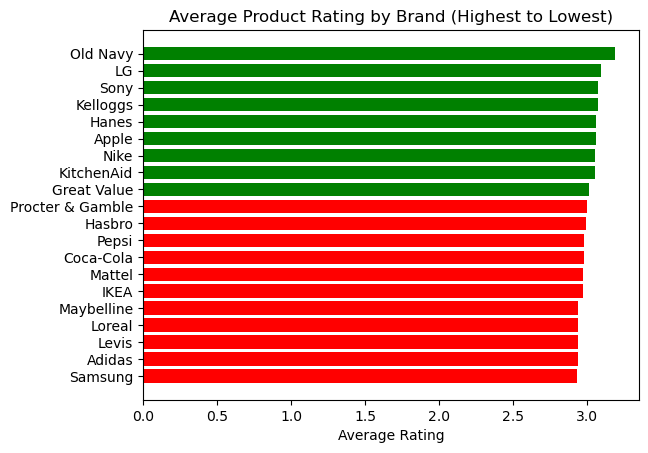

In [58]:
colors = ['red' if status == 'LOW' else 'green' for status in brand_ratings['rating_status']]

plt.barh(brand_ratings['brand'], brand_ratings['avg_rating'], color=colors)
plt.xlabel('Average Rating')
plt.title('Average Product Rating by Brand (Highest to Lowest)')
plt.gca().invert_yaxis() 
plt.show()


In [59]:
query = """
SELECT 
p.category,
COUNT(r.review_id) AS num_reviews,
ROUND(AVG(r.rating), 2) AS avg_rating,
CASE 
 WHEN AVG(r.rating) < 3.0 THEN 'LOW'
ELSE ' OK'
END AS rating_status
FROM products p
JOIN reviews r ON p.product_id = r.product_id
GROUP BY p.category
ORDER BY avg_rating ASC
"""
category_ratings = pd.read_sql(query, conn)
category_ratings

,category,num_reviews,avg_rating,rating_status
0,Grocery,1722,2.96,LOW
1,Home & Kitchen,1678,2.97,LOW
2,Health & Beauty,1501,3.01,OK
3,Clothing,1562,3.03,OK
4,Electronics,1737,3.05,OK
5,Toys,1800,3.06,OK


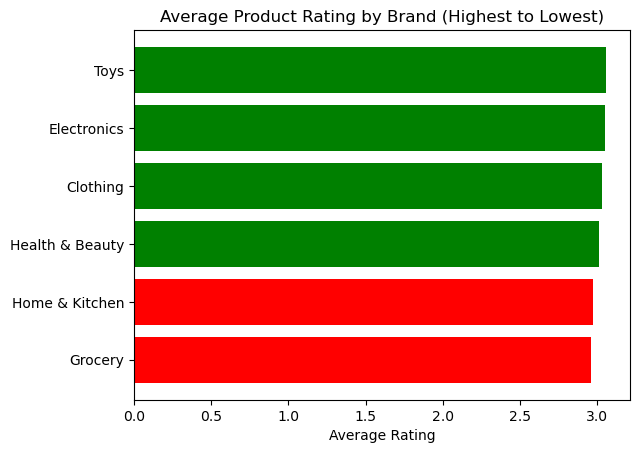

In [60]:
colors = ['red' if status == 'LOW' else 'green' for status in category_ratings['rating_status']]

plt.barh(category_ratings['category'], category_ratings['avg_rating'], color=colors)
plt.xlabel('Average Rating')
plt.title('Average Product Rating by Brand (Highest to Lowest)')
plt.gca()
plt.show()